In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sys
sys.path.append("/home/z5297792/UNSW-MRes/MRes/modules") 
from utils import unit_det


In [2]:
width=500
x = np.linspace(-width // 2, width // 2, 501)
y = np.linspace(-width // 2, width // 2, 501)
X, Y = np.meshgrid(x, y, indexing='ij')

xc, yc = 0.0, 0.0
Q11, Q12, Q22 = 1, .4, 1
psi0 = 250.0 
Rc = 85.0 
A = - psi0 / Rc**2

# rescale Q to have unit determinant
Q, _ = unit_det(Q=np.array([[Q11, Q12], [Q12, Q22]]))
q11, q12, q22 = Q[0,0], Q[0,1], Q[1,1]

w = 2*A*(q11+q22)*1e-3
Omega = 2*A*1e-3

dx, dy = X - xc, Y - yc
rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2
Qr2 = (q11*dx + q12*dy)**2 + (q12*dx + q22*dy)**2 # ||Qr||
psi = psi0 * np.exp( - rho2 / Rc**2 )
u =   psi0 * np.exp( - rho2 / Rc**2 ) * ( 2*q12*dx + 2*q22*dy ) / Rc**2
v = - psi0 * np.exp( - rho2 / Rc**2 ) * ( 2*q11*dx + 2*q12*dy ) / Rc**2


In [3]:
def doppio_pipeliner(nxc, nyc, ut, vt, X_new, Y_new, r=30_000.0):
    nan = (np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan)

    x = np.asarray(X_new[:, 0], float)
    y = np.asarray(Y_new[0, :], float)

    dx = np.nanmedian(np.abs(np.diff(x)))
    dy = np.nanmedian(np.abs(np.diff(y)))
    cell = np.nanmax([dx, dy])
    if not np.isfinite(cell) or cell == 0:
        return nan

    margin = int(np.ceil(r / cell))

    ic = int(np.clip(np.searchsorted(x, nxc), 1, x.size-1))
    ic -= (nxc - x[ic-1] < x[ic] - nxc)
    jc = int(np.clip(np.searchsorted(y, nyc), 1, y.size-1))
    jc -= (nyc - y[jc-1] < y[jc] - nyc)

    if ic < margin or ic >= x.size - margin or jc < margin or jc >= y.size - margin:
        return nan

    # x-transect (y = y[jc])
    i0 = np.searchsorted(x, nxc - r, side="left")
    i1 = np.searchsorted(x, nxc + r, side="right")
    x1 = x[i0:i1]
    y1 = np.full(x1.size, y[jc])
    u1 = ut[i0:i1, jc]
    v1 = vt[i0:i1, jc]

    # y-transect (x = x[ic])
    j0 = np.searchsorted(y, nyc - r, side="left")
    j1 = np.searchsorted(y, nyc + r, side="right")
    y2 = y[j0:j1]
    x2 = np.full(y2.size, x[ic])
    u2 = ut[ic, j0:j1]
    v2 = vt[ic, j0:j1]

    return x1, y1, u1, v1, x2, y2, u2, v2
    

In [4]:
def find_root(x, y, degree=3):
    if x.size < degree + 1:
        return np.nan

    try:
        coeffs = np.polyfit(x, y, degree)
        roots = np.roots(coeffs)
    except Exception:
        return np.nan

    real_roots = roots[np.isreal(roots)].real
    if real_roots.size == 0:
        return np.nan

    mid_x = np.median(x)
    return real_roots[np.argmin(np.abs(real_roots - mid_x))]



In [5]:
def plotter(nxc=0.0, nyc=0.0):
    
    fig, axs = plt.subplots(2, 2, figsize=(8,8))
    
    axs[0,0].pcolor(x, y, np.hypot(u, v), cmap='Blues_r')
    spac = 20
    axs[0,0].quiver(x[::spac], y[::spac], u[::spac,::spac].T, v[::spac,::spac].T, scale=40)
    axs[0,0].axis('equal')
    
    
    x1, y1, u1, v1, x2, y2, u2, v2 = doppio_pipeliner(nxc, nyc, u.T, v.T, X, Y, r=30.0)
    # x1, y1, x2, y2 = np.flip(x1), np.flip(y1), np.flip(x2), np.flip(y2)
    axs[0,0].plot(x1, y1, color='r'); axs[0,0].plot(x2, y2, color='r')
    
    width=0.002
    scale=20
    axs[0,1].quiver(x1, y1, u1, v1, scale=scale, width=width); axs[0,1].quiver(x2, y2, u2, v2, scale=scale, width=width);
    x0 = find_root(x1, v1)
    y0 = find_root(y2, u2)
    print(f'x0={x0}, y0={y0}')
    axs[0,1].axvline(x0); axs[0,1].axhline(y0)
    axs[0,1].scatter(0, 0, marker='x', s=50, color='r')
    
    axs[1,0].plot(x1, v1)
    axs[1,0].axvline(x0); axs[1,0].axhline(0, lw=.5, color='k'); axs[1,0].axvline(0, lw=.5, color='k')
    
    axs[1,1].plot(y2, u2)
    axs[1,1].axvline(y0); axs[1,1].axhline(0, lw=.5, color='k'); axs[1,1].axvline(0, lw=.5, color='k')
    
    plt.tight_layout()


x0=-6.123139024025963e-16, y0=-6.123139024025963e-16


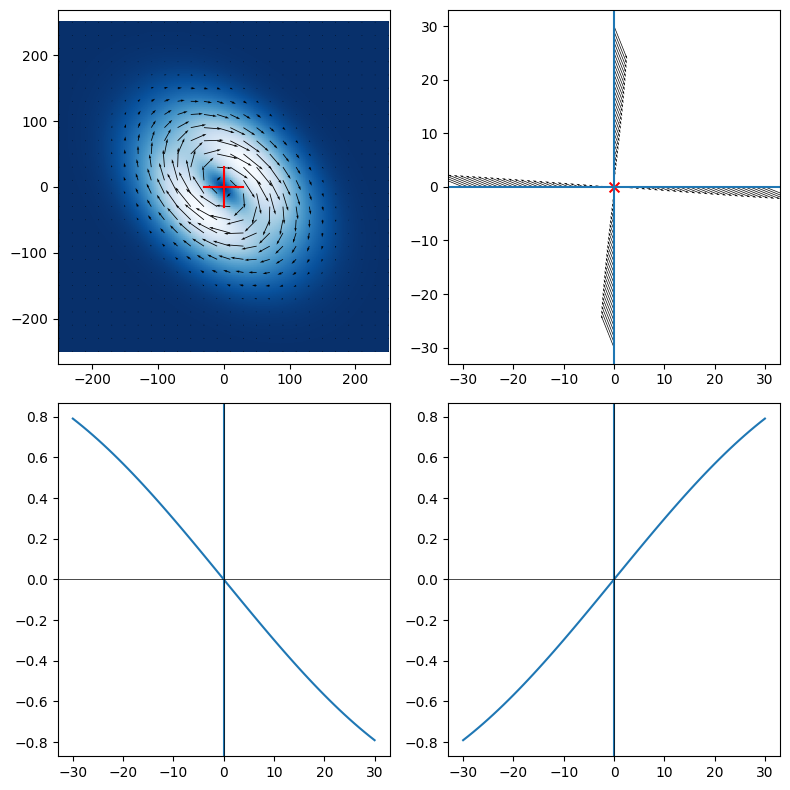

In [6]:
plotter()


x0=-12.533481295978724, y0=-12.533481295978724


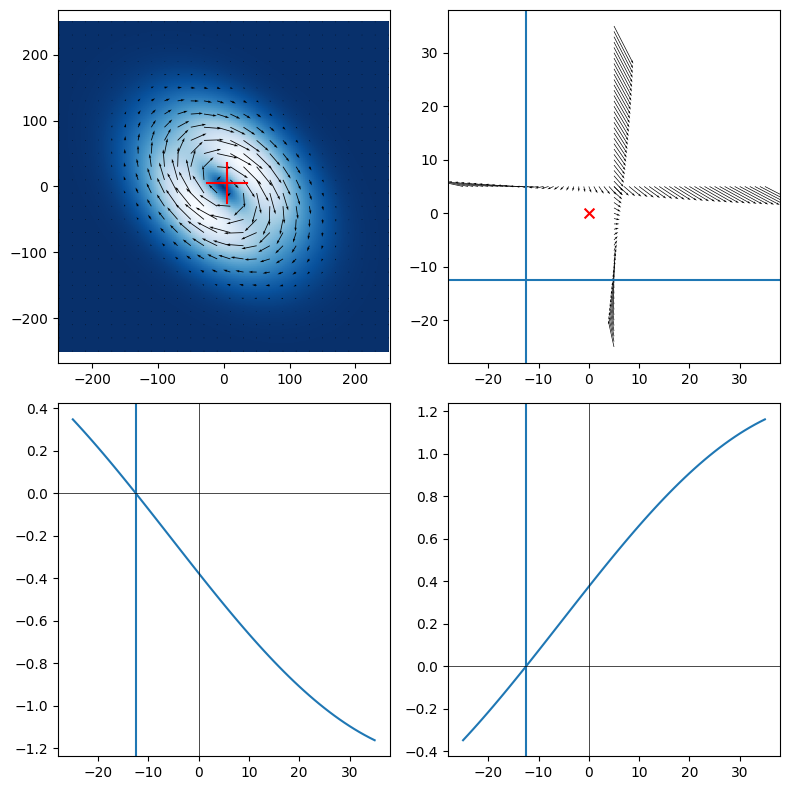

In [7]:
plotter(nxc=5.0, nyc=5.0)


x0=-24.613090049467328, y0=-24.613090049467328


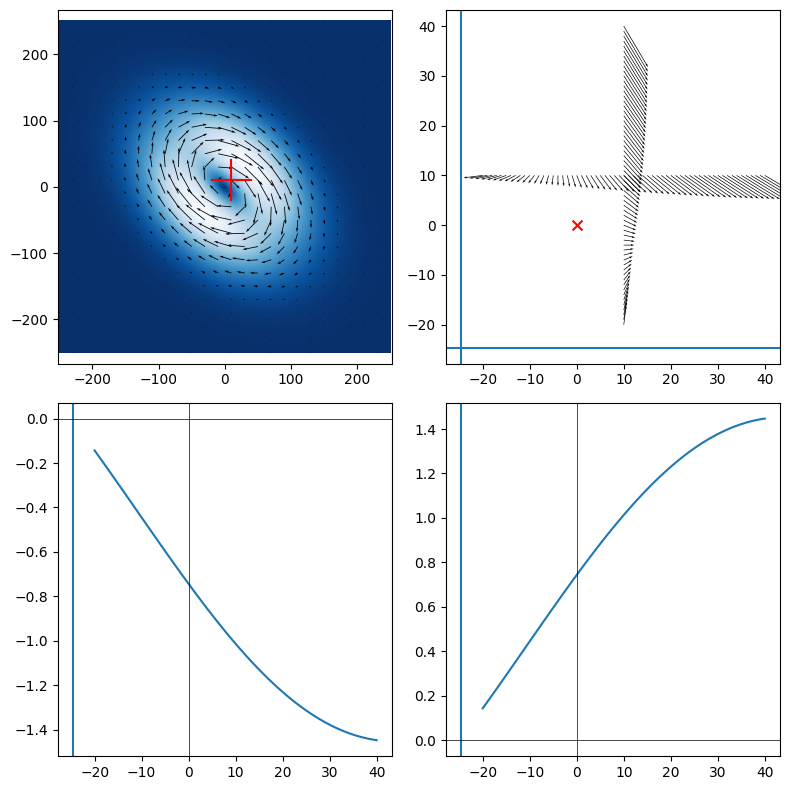

In [8]:
plotter(nxc=10.0, nyc=10.0)


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


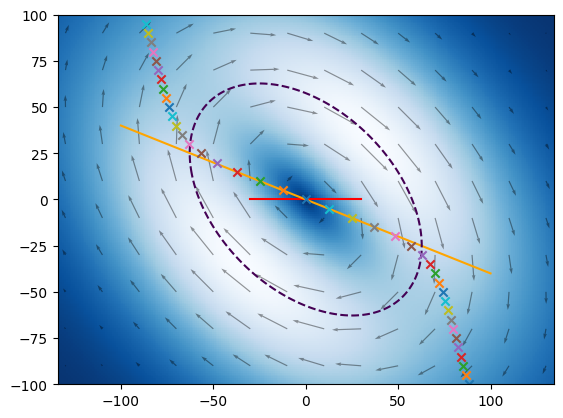

In [38]:
fig, ax = plt.subplots()
ax.pcolor(x, y, np.hypot(u, v), cmap='Blues_r')
spac = 20
ax.quiver(x[::spac], y[::spac], u[::spac,::spac].T, v[::spac,::spac].T, scale=40, alpha=.4)

ax.axis('equal')
ax.set_xlim(-100, 100)
ax.set_ylim(-100, 100)

dx_ell, dy_ell = X, Y
rho2_ell = q11*dx_ell**2 + 2*q12*dx_ell*dy_ell + q22*dy_ell**2
ax.contour(X, Y, rho2_ell, levels=[Rc**2/2], linestyles='--')

for nyc in range(-100, 100, 5):

    x1, y1, u1, v1, *_ = doppio_pipeliner(0.0, nyc, u.T, v.T, X, Y, r=30.0)

    if nyc == 0:
        plt.plot(x1, y1, color='r', zorder=1)

    x0 = find_root(x1, v1)
    y0 = nyc
    plt.scatter(x0, y0, marker='x', zorder=2)


xT = np.linspace(-100, 100, 100)
y0 = -q12/q22 * xT
ax.plot(xT, y0, color='orange', zorder=1)


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


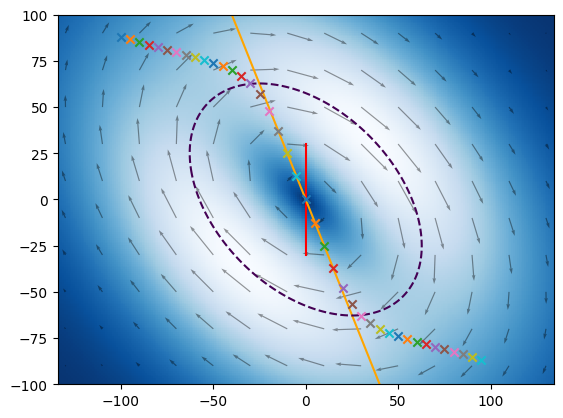

In [37]:
fig, ax = plt.subplots()
ax.pcolor(x, y, np.hypot(u, v), cmap='Blues_r')
spac = 20
ax.quiver(x[::spac], y[::spac], u[::spac,::spac].T, v[::spac,::spac].T, scale=40, alpha=.4)

ax.axis('equal')
ax.set_xlim(-100, 100)
ax.set_ylim(-100, 100)

dx_ell, dy_ell = X, Y
rho2_ell = q11*dx_ell**2 + 2*q12*dx_ell*dy_ell + q22*dy_ell**2
ax.contour(X, Y, rho2_ell, levels=[Rc**2/2], linestyles='--')

for nxc in range(-100, 100, 5):

    _, _, _, _, x2, y2, u2, v2 = doppio_pipeliner(nxc, 0.0, u.T, v.T, X, Y, r=30.0)

    if nxc == 0:
        plt.plot(x2, y2, color='r', zorder=1)

    x0 = nxc 
    y0 = find_root(y2, u2)
    plt.scatter(x0, y0, marker='x', zorder=2)

yT = np.linspace(-100, 100, 100)
x0 = -q12/q11 * yT
ax.plot(x0, yT, color='orange', zorder=1)


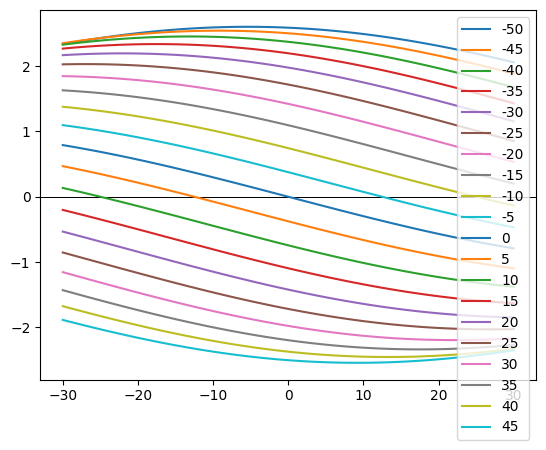

In [48]:
for nyc in range(-50, 50, 5):

    x1, y1, u1, v1, *_ = doppio_pipeliner(0.0, nyc, u.T, v.T, X, Y, r=30.0)

    # x0 = find_root(x1, v1)
    # y0 = nyc
    # # plt.scatter(x0, y0, marker='x', zorder=2)
    # plt.axvline(x0)
    plt.plot(x1, v1, label=nyc)
    plt.axhline(0, lw=.5, color='k', zorder=0)
plt.legend()
